4 Clustering Techniques
Segment customers into meaningful groups based on their spending behaviour and income using 2 Clustering Algorithms.
Dataset: Mall Customers
Tasks:
1. Perform Data Pre-processing (Encoding, Scaling).
2. Apply K-Means and at least one other clustering algorithm (e.g., Hierarchical).
3. Visualize the clusters formed based on Spending Score and Annual Income.
4. Evaluate and compare the cluster quality using metrics such as Elbow method and Silhouette Score.
5. Apply Cross-Validation if applicable.

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv("/content/Clustering_Mall_Customers.csv")

In [ ]:
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
#labelEncoding
from sklearn.preprocessing import LabelEncoder
label=LabelEncoder()
df['Genre']=label.fit_transform(df['Genre'])

In [ ]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [ ]:
# Drop CustomerID as its not useful
data = df.drop(['CustomerID'], axis=1)
data.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [ ]:
X = df[['Annual Income (k$)','Spending Score (1-100)']]

In [ ]:
from sklearn.model_selection import train_test_split
# Optional split (for evaluation)
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)


In [ ]:
from sklearn.cluster import KMeans
# KMeans with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

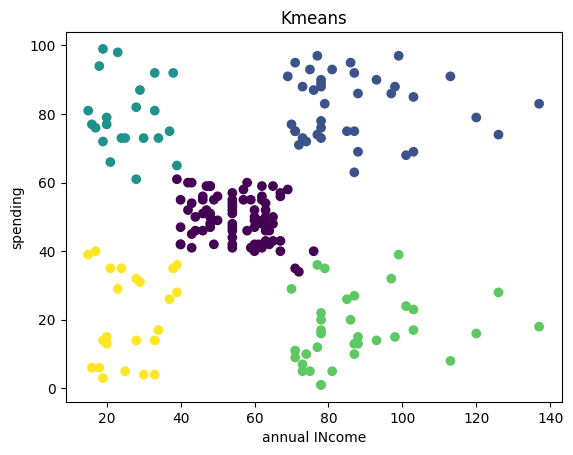

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'], c=kmeans_labels)
plt.xlabel("annual INcome")
plt.ylabel("spending")
plt.title("Kmeans")
plt.show()


In [ ]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=5)
y_agg = agg.fit_predict(X)


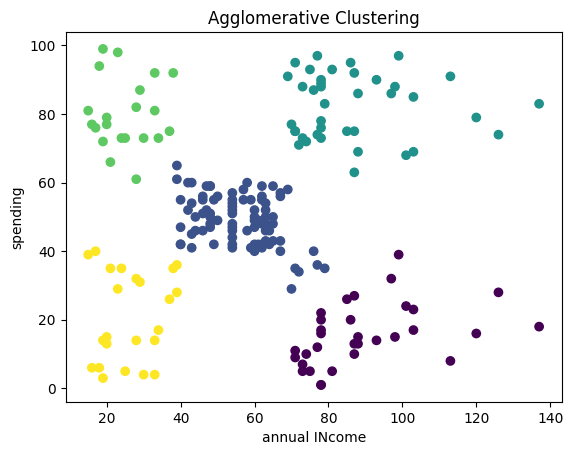

In [ ]:
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'], c=y_agg)
plt.xlabel("annual INcome")
plt.ylabel("spending")
plt.title("Agglomerative Clustering")
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score

print("Silhouette (KMeans):", silhouette_score(X,kmeans_labels ))
print("Silhouette (Agglomerative):", silhouette_score(X, y_agg))


Silhouette (KMeans): 0.553931997444648
Silhouette (Agglomerative): 0.5529945955148897


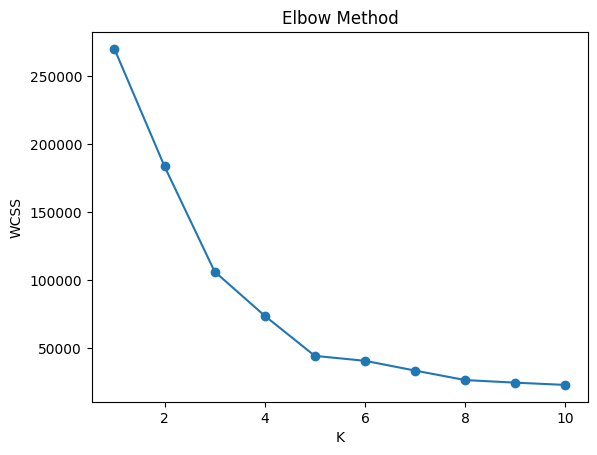

In [ ]:
#Elbow Method
wcss = []
for i in range(1,11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()
